Author: Pia Rautenstrauch
Date: 3rd of April, 2025

Application of batch removal metrics on real data.

Data: "snRNA-seq analyses of breast tissues of healthy women of diverse genetic ancestry"
- https://cellxgene.cziscience.com/collections/77446b76-1c2d-4a71-8e59-0efd4374d98e
- https://www.nature.com/articles/s41591-024-03011-9
- diverse anchestry, all healthy

We use data as provided as part of the anndata objects.
- Integrated (RNA PCA embedding as provided as part of the anndata object availabe via CellxGene)
- Unintegrated (None)
- Mild batch correction by highly variable gene selection (Suboptimal)



- run on maxg16
- conda env: scib_metrics

In [1]:
import scanpy as sc
import anndata as ad
import scib
import numpy as np
import pandas as pd
import warnings

In [2]:
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=ad.OldFormatWarning)

In [3]:
adata = ad.read_h5ad('./../../data/original/63a485bc-cac7-49d2-83ed-8e07ca4efa2a.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 51367 × 36406
    obs: 'mapped_reference_annotation', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_living_at_sample_collection', 'donor_menopausal_status', 'organism_ontology_term_id', 'donor_times_pregnant', 'sample_uuid', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_derivation_process', 'menstrual_phase_at_collection', 'sample_source', 'donor_BMI_at_collection', 'tissue_type', 'suspension_derivation_process', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_uuid', 'assay_ontology_term_id', 'library_starting_quantity', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'celltype', 'ML_sub', 'Basal_sub', 'epi_sub', 'LP_sub', 'LHS_sub', 'LASP_sub', 'Group', 'Pool', 'nFeature_ATAC', 'nCount_RNA', 'nCount_SCT', 'nucleosome_perc

In [5]:
## Integrated

In [6]:
# check if provided X_pca is batch corrrected --> it is

/fast/AG_Ohler/prauten/conda_envs/scib_metrics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


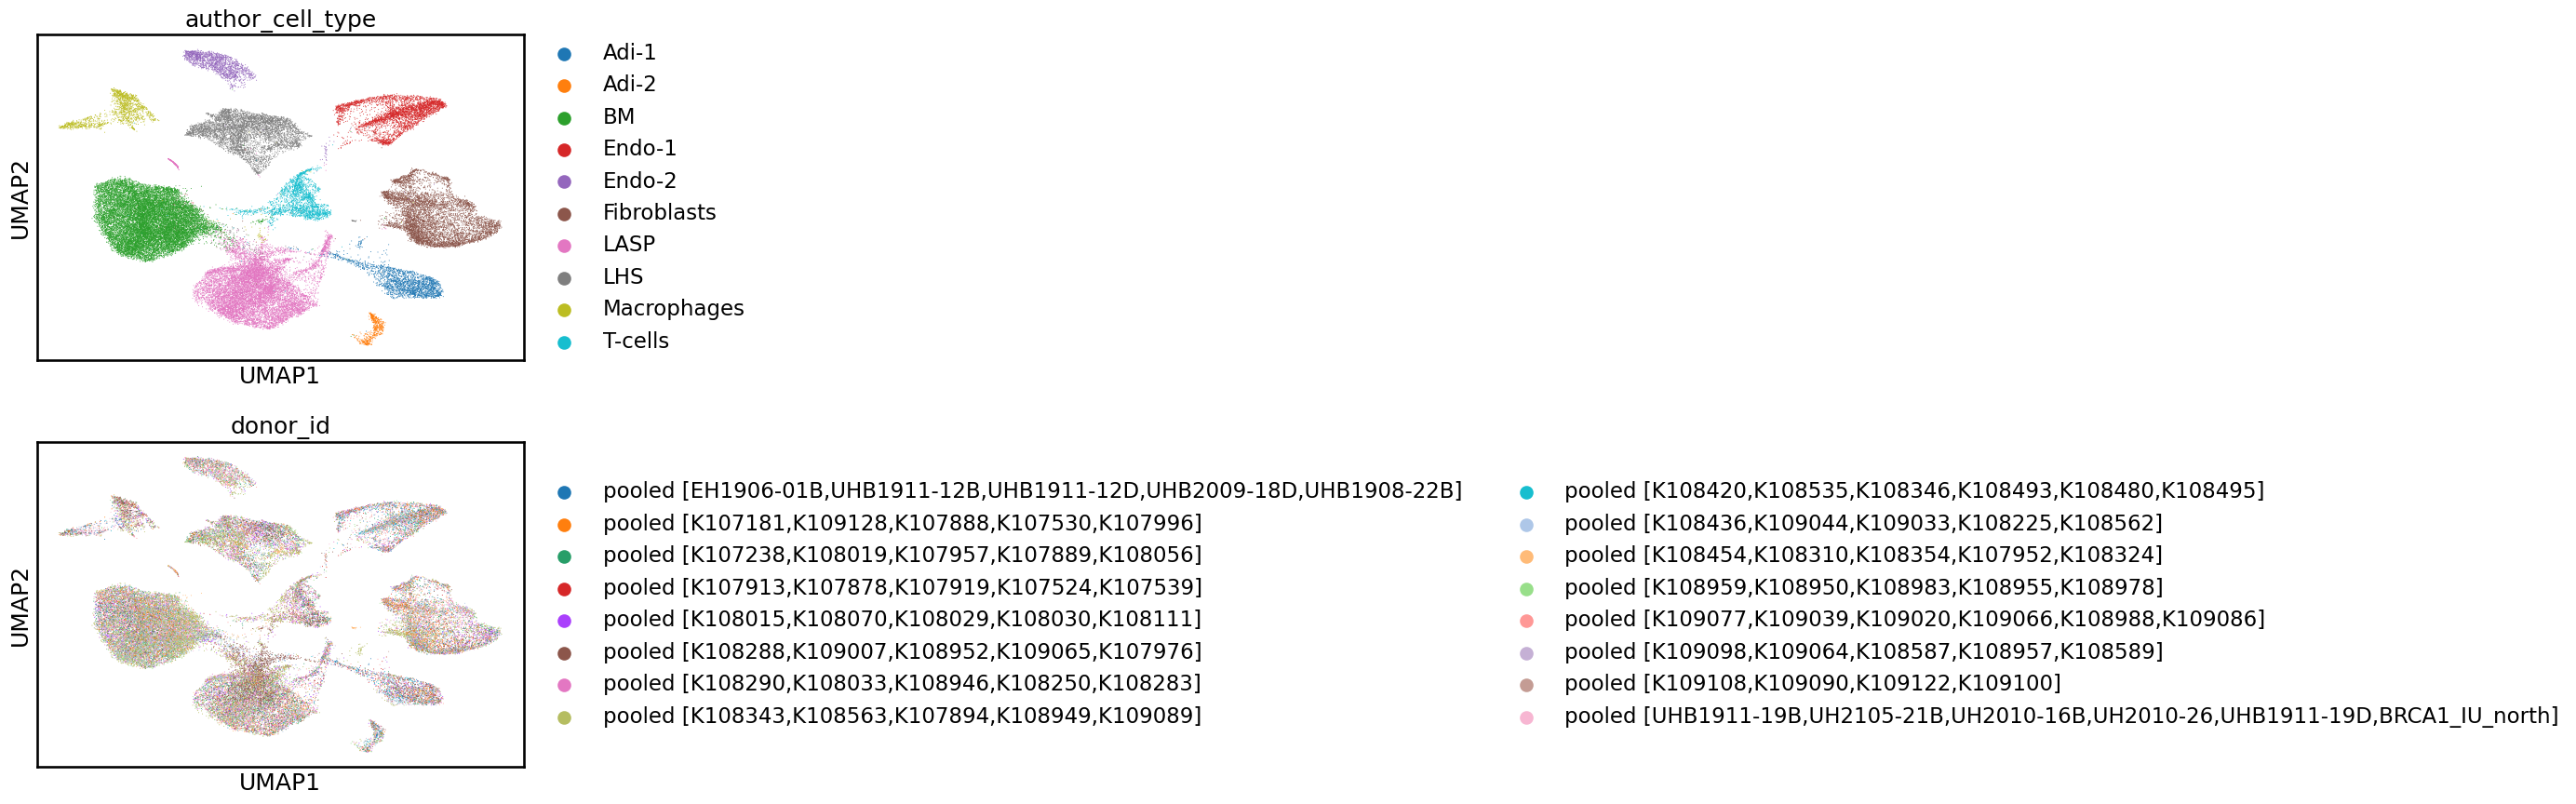

In [7]:
sc.pp.neighbors(adata)

sc.tl.umap(adata)

sc.pl.umap(
    adata,
    ncols=1,
    color=["author_cell_type", "donor_id"],
    size=2,
)

In [8]:
model = 'integration_hbca'

In [9]:
# Save embedding
embedding = ad.AnnData(
    X=adata.obsm['X_pca'],
    obs=adata.obs,
    uns={
        'method_id': model,
    }
)
embedding.write_h5ad("./../../embeddings/{}.embedding.h5ad".format(model), compression="gzip")

In [10]:
# Check if data in adata.X is normalized --> it is

In [11]:
adata.X.min()

0.0

In [12]:
adata.X.max()

6.8906093

In [13]:
## Unintegrated 

In [14]:
model = 'noIntegration_hbca'

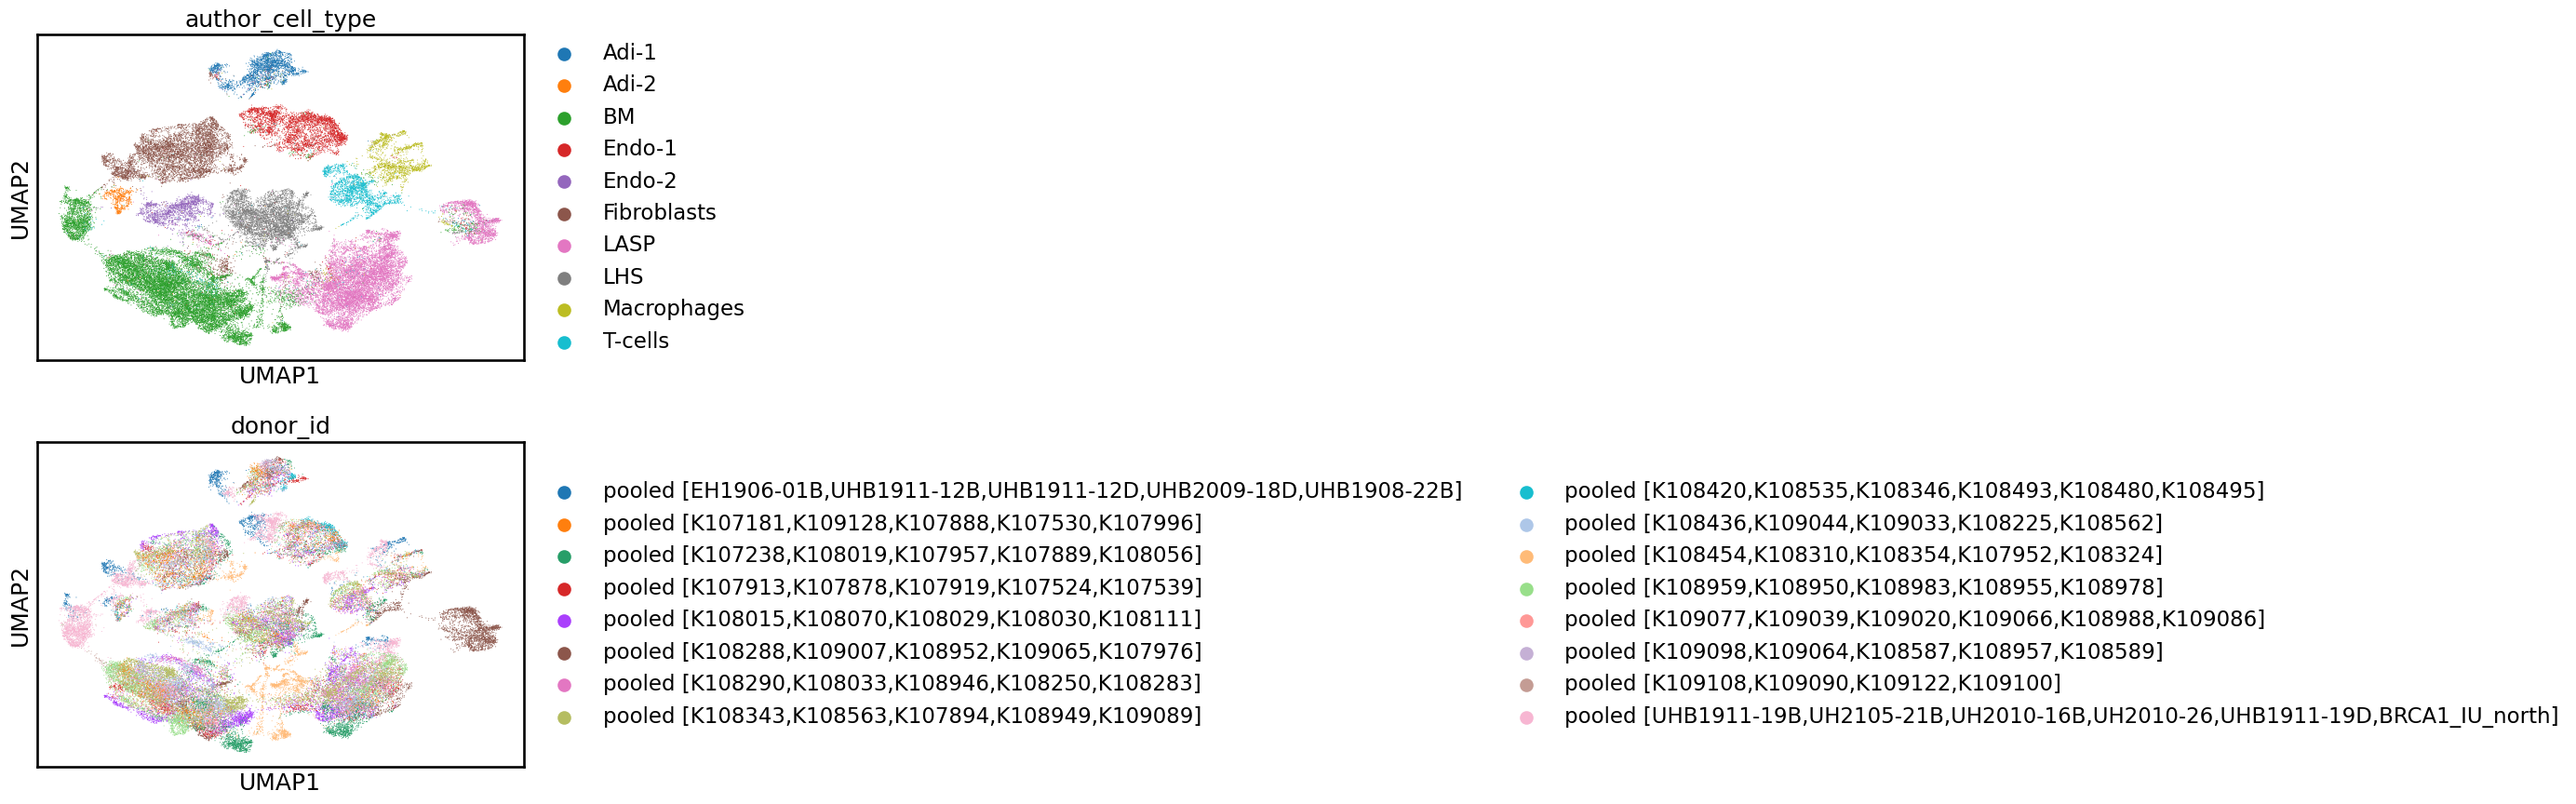

In [15]:
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    ncols=1,
    color=["author_cell_type", "donor_id"],
    size=2,
)

In [16]:
# Save embedding
embedding = ad.AnnData(
    X=adata.obsm['X_pca'],
    obs=adata.obs,
    uns={
        'method_id': model,
    }
)
embedding.write_h5ad("./../../embeddings/{}.embedding.h5ad".format(model), compression="gzip")

In [17]:
## Naive integration

In [18]:
model = 'naiveIntegration_donor_id_hbca'

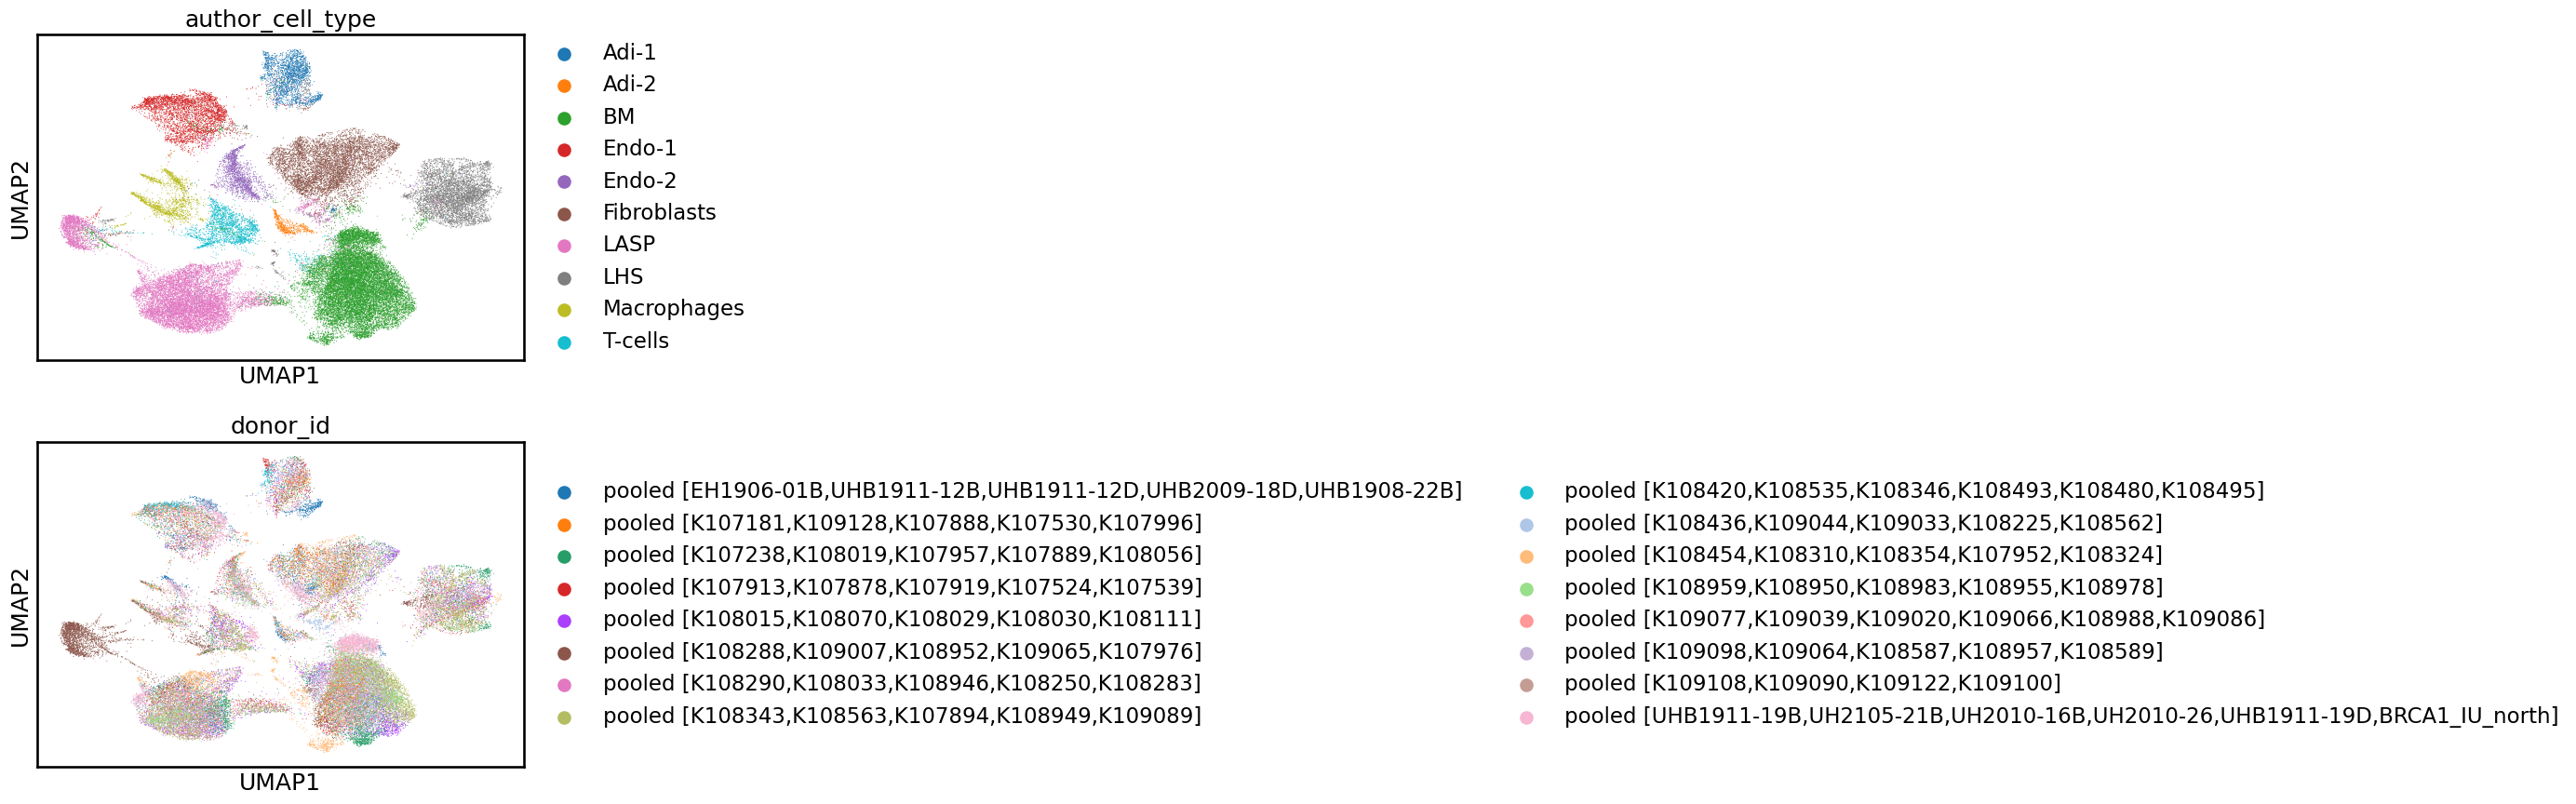

In [19]:
# Mild batch correction by batch-aware selection of highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="donor_id")

sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    ncols=1,
    color=["author_cell_type", "donor_id"],
    size=2,
)

In [20]:
# Save embedding
embedding = ad.AnnData(
    X=adata.obsm['X_pca'],
    obs=adata.obs,
    uns={
        'method_id': model,
    }
)
embedding.write_h5ad("./../../embeddings/{}.embedding.h5ad".format(model), compression="gzip")